# 🔗 Final Integration — Team Effort
## Multimodal Crime / Incident Report Analyzer

### Objective:
Merge all 5 structured outputs into a unified incident dataset with severity classification and a simple dashboard.

### Steps:
1. Load all 5 CSVs
2. Assign common Incident_IDs
3. Merge into unified DataFrame
4. Severity classification
5. Dashboard visualization


In [1]:
# =============================================
# CELL 1: Install Dependencies
# =============================================
!pip install -q pandas matplotlib seaborn

In [10]:
# =============================================
# CELL 2: Import Libraries
# =============================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 150

print("Libraries loaded!")


Libraries loaded!


In [9]:
# =============================================
# CELL 3: Load All 5 Output CSVs
# =============================================

# Paths to each analyst's output
csv_paths = {
    "audio": "/content/audio_analyst_output.csv",
    "document": "/content/document_analyst_output.csv",
    "image": "/content/image_analyst_output.csv",
    "video": "/content/video_analyst_output.csv",
    "text": "/content/text_analyst_output.csv"
}

dataframes = {}
for modality, path in csv_paths.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        dataframes[modality] = df
        print(f"Loaded {modality}: {len(df)} rows, columns: {list(df.columns)}")
    else:
        print(f"WARNING: {path} not found. Run the {modality} analyst notebook first.")

print(f"\nLoaded {len(dataframes)}/5 modality outputs.")


Loaded audio: 703 rows, columns: ['Call_ID', 'Transcript', 'Extracted_Event', 'Location', 'Sentiment', 'Urgency_Score']
Loaded document: 10 rows, columns: ['Report_ID', 'Department', 'Doc_Type', 'Date', 'Program', 'Key_Detail']
Loaded image: 5000 rows, columns: ['Image_ID', 'Scene_Type', 'Objects_Detected', 'Bounding_Boxes', 'Text_Extracted', 'Confidence_Score']
Loaded video: 284 rows, columns: ['Clip_ID', 'Timestamp', 'Frame_ID', 'Event_Detected', 'Persons_Count', 'Confidence_Score']
Loaded text: 115 rows, columns: ['Text_ID', 'Crime_Type', 'Location_Entity', 'Sentiment', 'Topic', 'Severity_Label']

Loaded 5/5 modality outputs.


In [12]:
# =============================================
# CELL 4: Assign Common Incident IDs & Standardize
# =============================================

def standardize_audio(df):
    result = df.copy()
    result["Source_Modality"] = "Audio"
    result.rename(columns={
        "Extracted_Event": "Event_Type",
        "Urgency_Score": "Confidence_Score"
    }, inplace=True)
    return result[["Source_Modality", "Event_Type", "Location", "Sentiment", "Confidence_Score"]]

def standardize_document(df):
    result = df.copy()
    result["Source_Modality"] = "PDF"
    result.rename(columns={
        "Doc_Type": "Event_Type"
    }, inplace=True)
    result["Confidence_Score"] = 0.90
    result["Sentiment"] = "Neutral"
    result["Location"] = result.get("Department", "Unknown")
    return result[["Source_Modality", "Event_Type", "Location", "Sentiment", "Confidence_Score"]]

def standardize_image(df):
    result = df.copy()
    result["Source_Modality"] = "Image"
    result.rename(columns={
        "Scene_Type": "Event_Type"
    }, inplace=True)
    result["Sentiment"] = "N/A"
    result["Location"] = "Scene Image"
    return result[["Source_Modality", "Event_Type", "Location", "Sentiment", "Confidence_Score"]]

def standardize_video(df):
    result = df.copy()
    result["Source_Modality"] = "Video"
    result.rename(columns={
        "Event_Detected": "Event_Type"
    }, inplace=True)
    result["Sentiment"] = "N/A"
    result["Location"] = "CCTV Footage"
    return result[["Source_Modality", "Event_Type", "Location", "Sentiment", "Confidence_Score"]]

def standardize_text(df):
    result = df.copy()
    result["Source_Modality"] = "Text"
    result.rename(columns={
        "Crime_Type": "Event_Type",
        "Location_Entity": "Location"
    }, inplace=True)
    result["Confidence_Score"] = 0.85
    return result[["Source_Modality", "Event_Type", "Location", "Sentiment", "Confidence_Score"]]

# Standardize all
standardizers = {
    "audio": standardize_audio,
    "document": standardize_document,
    "image": standardize_image,
    "video": standardize_video,
    "text": standardize_text
}

standardized = {}
for modality, df in dataframes.items():
    if modality in standardizers:
        standardized[modality] = standardizers[modality](df)
        print(f"Standardized {modality}: {len(standardized[modality])} rows")

Standardized audio: 703 rows
Standardized document: 10 rows
Standardized image: 5000 rows
Standardized video: 284 rows
Standardized text: 115 rows


In [13]:
# =============================================
# CELL 5: Merge into Unified Dataset (Simulated Cross-Modal Join)
# =============================================

# Since each modality uses independent datasets (not the same real incidents),
# we simulate a cross-modal merge by aligning rows across modalities.
# In production, a shared Incident_ID would link data from the same real event.

# Find the minimum row count across all modalities for alignment
min_rows = min(len(df) for df in standardized.values())
print(f"Aligning on {min_rows} incidents (limited by smallest modality)\n")

# Assign matching Incident_IDs to first min_rows of each modality
aligned_dfs = []
for modality, df in standardized.items():
    df_aligned = df.head(min_rows).copy()
    df_aligned["Incident_ID"] = [f"INC_{i:03d}" for i in range(1, min_rows + 1)]
    aligned_dfs.append(df_aligned)

# Merge all modalities on Incident_ID
df_merged = aligned_dfs[0]
for df_next in aligned_dfs[1:]:
    df_merged = pd.merge(df_merged, df_next, on="Incident_ID", suffixes=("", f"_{df_next['Source_Modality'].iloc[0]}"))

print(f"Merged dataset: {len(df_merged)} incidents × {len(df_merged.columns)} columns")
print(f"Columns: {list(df_merged.columns)}")
df_merged.head()

# Also create a long-format version (all rows stacked) for visualizations
all_dfs = []
for modality, df in standardized.items():
    df_copy = df.copy()
    df_copy["Incident_ID"] = [f"INC_{i:03d}" for i in range(1, len(df_copy) + 1)]
    all_dfs.append(df_copy)

df_unified = pd.concat(all_dfs, ignore_index=True)
df_unified.fillna("N/A", inplace=True)
print(f"\nLong-format dataset: {len(df_unified)} total rows across {len(dataframes)} modalities")
print(f"\nModality distribution:")
print(df_unified["Source_Modality"].value_counts())

Aligning on 10 incidents (limited by smallest modality)

Merged dataset: 10 incidents × 26 columns
Columns: ['Source_Modality', 'Event_Type', 'Location', 'Sentiment', 'Confidence_Score', 'Incident_ID', 'Source_Modality_PDF', 'Event_Type_PDF', 'Location_PDF', 'Sentiment_PDF', 'Confidence_Score_PDF', 'Source_Modality_Image', 'Event_Type_Image', 'Location_Image', 'Sentiment_Image', 'Confidence_Score_Image', 'Source_Modality_Video', 'Event_Type_Video', 'Location_Video', 'Sentiment_Video', 'Confidence_Score_Video', 'Source_Modality_Text', 'Event_Type_Text', 'Location_Text', 'Sentiment_Text', 'Confidence_Score_Text']

Long-format dataset: 6112 total rows across 5 modalities

Modality distribution:
Source_Modality
Image    5000
Audio     703
Video     284
Text      115
PDF        10
Name: count, dtype: int64


In [14]:
# =============================================
# CELL 6: Final Severity Classification
# =============================================

def assign_severity(row):
    """Assign severity based on event type, confidence, and sentiment."""
    event = str(row.get("Event_Type", "")).lower()
    confidence = float(row.get("Confidence_Score", 0.5))
    sentiment = str(row.get("Sentiment", "")).lower()

    # High severity events
    high_events = ["fire", "shooting", "assault", "trapped", "collapse", "altercation",
                   "explosion", "weapon", "stabbing", "aggravated"]
    # Medium severity events
    medium_events = ["accident", "theft", "robbery", "burglary", "break-in", "vehicle",
                     "collision", "injured", "fight"]
    # Low severity events
    low_events = ["suspicious", "disturbance", "noise", "walking", "normal",
                  "minor", "vandalism"]

    for kw in high_events:
        if kw in event:
            return "High"
    for kw in medium_events:
        if kw in event:
            return "Medium"
    for kw in low_events:
        if kw in event:
            return "Low"

    # Fallback based on confidence
    if confidence >= 0.85:
        return "Medium"
    return "Low"

df_unified["Severity"] = df_unified.apply(assign_severity, axis=1)

print("Severity distribution:")
print(df_unified["Severity"].value_counts())
print()
df_unified.head(10)


Severity distribution:
Severity
High      3530
Low       2269
Medium     313
Name: count, dtype: int64



,Source_Modality,Event_Type,Location,Sentiment,Confidence_Score,Incident_ID,Severity
0,Audio,Unknown,Unknown,Calm,0.0,INC_001,Low
1,Audio,Unknown,Unknown,Distressed,0.0,INC_002,Low
2,Audio,Unknown,Unknown,Calm,0.0,INC_003,Low
3,Audio,Unknown,Unknown,Calm,0.0,INC_004,Low
4,Audio,Unknown,Unknown,Distressed,0.0,INC_005,Low
5,Audio,Unknown,Unknown,Calm,0.0,INC_006,Low
6,Audio,Unknown,Unknown,Concerned,0.1,INC_007,Low
7,Audio,Unknown,Unknown,Distressed,0.0,INC_008,Low
8,Audio,Unknown,Unknown,Calm,0.0,INC_009,Low
9,Audio,Unknown,Unknown,Concerned,0.0,INC_010,Low


In [15]:
# =============================================
# CELL 7: Create Wide-Format Integrated Table
# =============================================

column_mapping = {
    "audio": "Audio_Event",
    "document": "PDF_Doc_Type",
    "image": "Image_Objects",
    "video": "Video_Event",
    "text": "Text_Crime_Type"
}

wide_data = []
min_rows = min(len(df) for df in standardized.values())

for i in range(min_rows):
    row = {"Incident_ID": f"INC_{i+1:03d}"}
    for modality, df in standardized.items():
        if i < len(df):
            row[column_mapping[modality]] = df.iloc[i]["Event_Type"]
        else:
            row[column_mapping[modality]] = "N/A"

    events_combined = " ".join(str(v) for v in row.values())
    row["Severity"] = assign_severity({"Event_Type": events_combined, "Confidence_Score": 0.85, "Sentiment": ""})
    wide_data.append(row)

df_wide = pd.DataFrame(wide_data)
df_wide.fillna("N/A", inplace=True)
print("INTEGRATED MULTI-MODAL VIEW (each row = same incident across all 5 modalities):")
df_wide

INTEGRATED MULTI-MODAL VIEW (each row = same incident across all 5 modalities):


,Incident_ID,Audio_Event,PDF_Doc_Type,Image_Objects,Video_Event,Text_Crime_Type,Severity
0,INC_001,Unknown,MRAP,Unknown,Person stationary (possible collapse),Shooting / Gun Violence,High
1,INC_002,Unknown,MRAP,Fire Scene,Person stationary (possible collapse),Shooting / Gun Violence,High
2,INC_003,Unknown,MRAP,Unknown,Person walking,Suspicious Activity,Low
3,INC_004,Unknown,MRAP,Unknown,Person stationary (possible collapse),Suspicious Activity,High
4,INC_005,Unknown,MRAP,Unknown,Normal / no activity,Suspicious Activity,Low
5,INC_006,Unknown,MRAP,Unknown,Normal / no activity,Suspicious Activity,Low
6,INC_007,Unknown,1033,Vehicle Accident,Normal / no activity,Robbery / Theft,Medium
7,INC_008,Unknown,MRAP,Unknown,Normal / no activity,Assault / Violence,High
8,INC_009,Unknown,MRAP,Unknown,Person stationary (possible collapse),Suspicious Activity,High
9,INC_010,Unknown,MRAP,Unknown,Person stationary (possible collapse),Drug-Related Crime,High


In [16]:
# =============================================
# CELL 8: Save Final Outputs
# =============================================

# Save unified (long format)
df_unified.to_csv("final_unified_incidents.csv", index=False)
print("Saved: final_unified_incidents.csv")

# Save wide format
df_wide.to_csv("final_integrated_wide.csv", index=False)
print("Saved: final_integrated_wide.csv")

# Save merged format
df_merged.to_csv("final_merged_incidents.csv", index=False)
print("Saved: final_merged_incidents.csv")

print(f"\nTotal records in unified dataset: {len(df_unified)}")
print(f"Total records in wide format: {len(df_wide)}")
print(f"Total records in merged format: {len(df_merged)}")

Saved: final_unified_incidents.csv
Saved: final_integrated_wide.csv
Saved: final_merged_incidents.csv

Total records in unified dataset: 6112
Total records in wide format: 10
Total records in merged format: 10


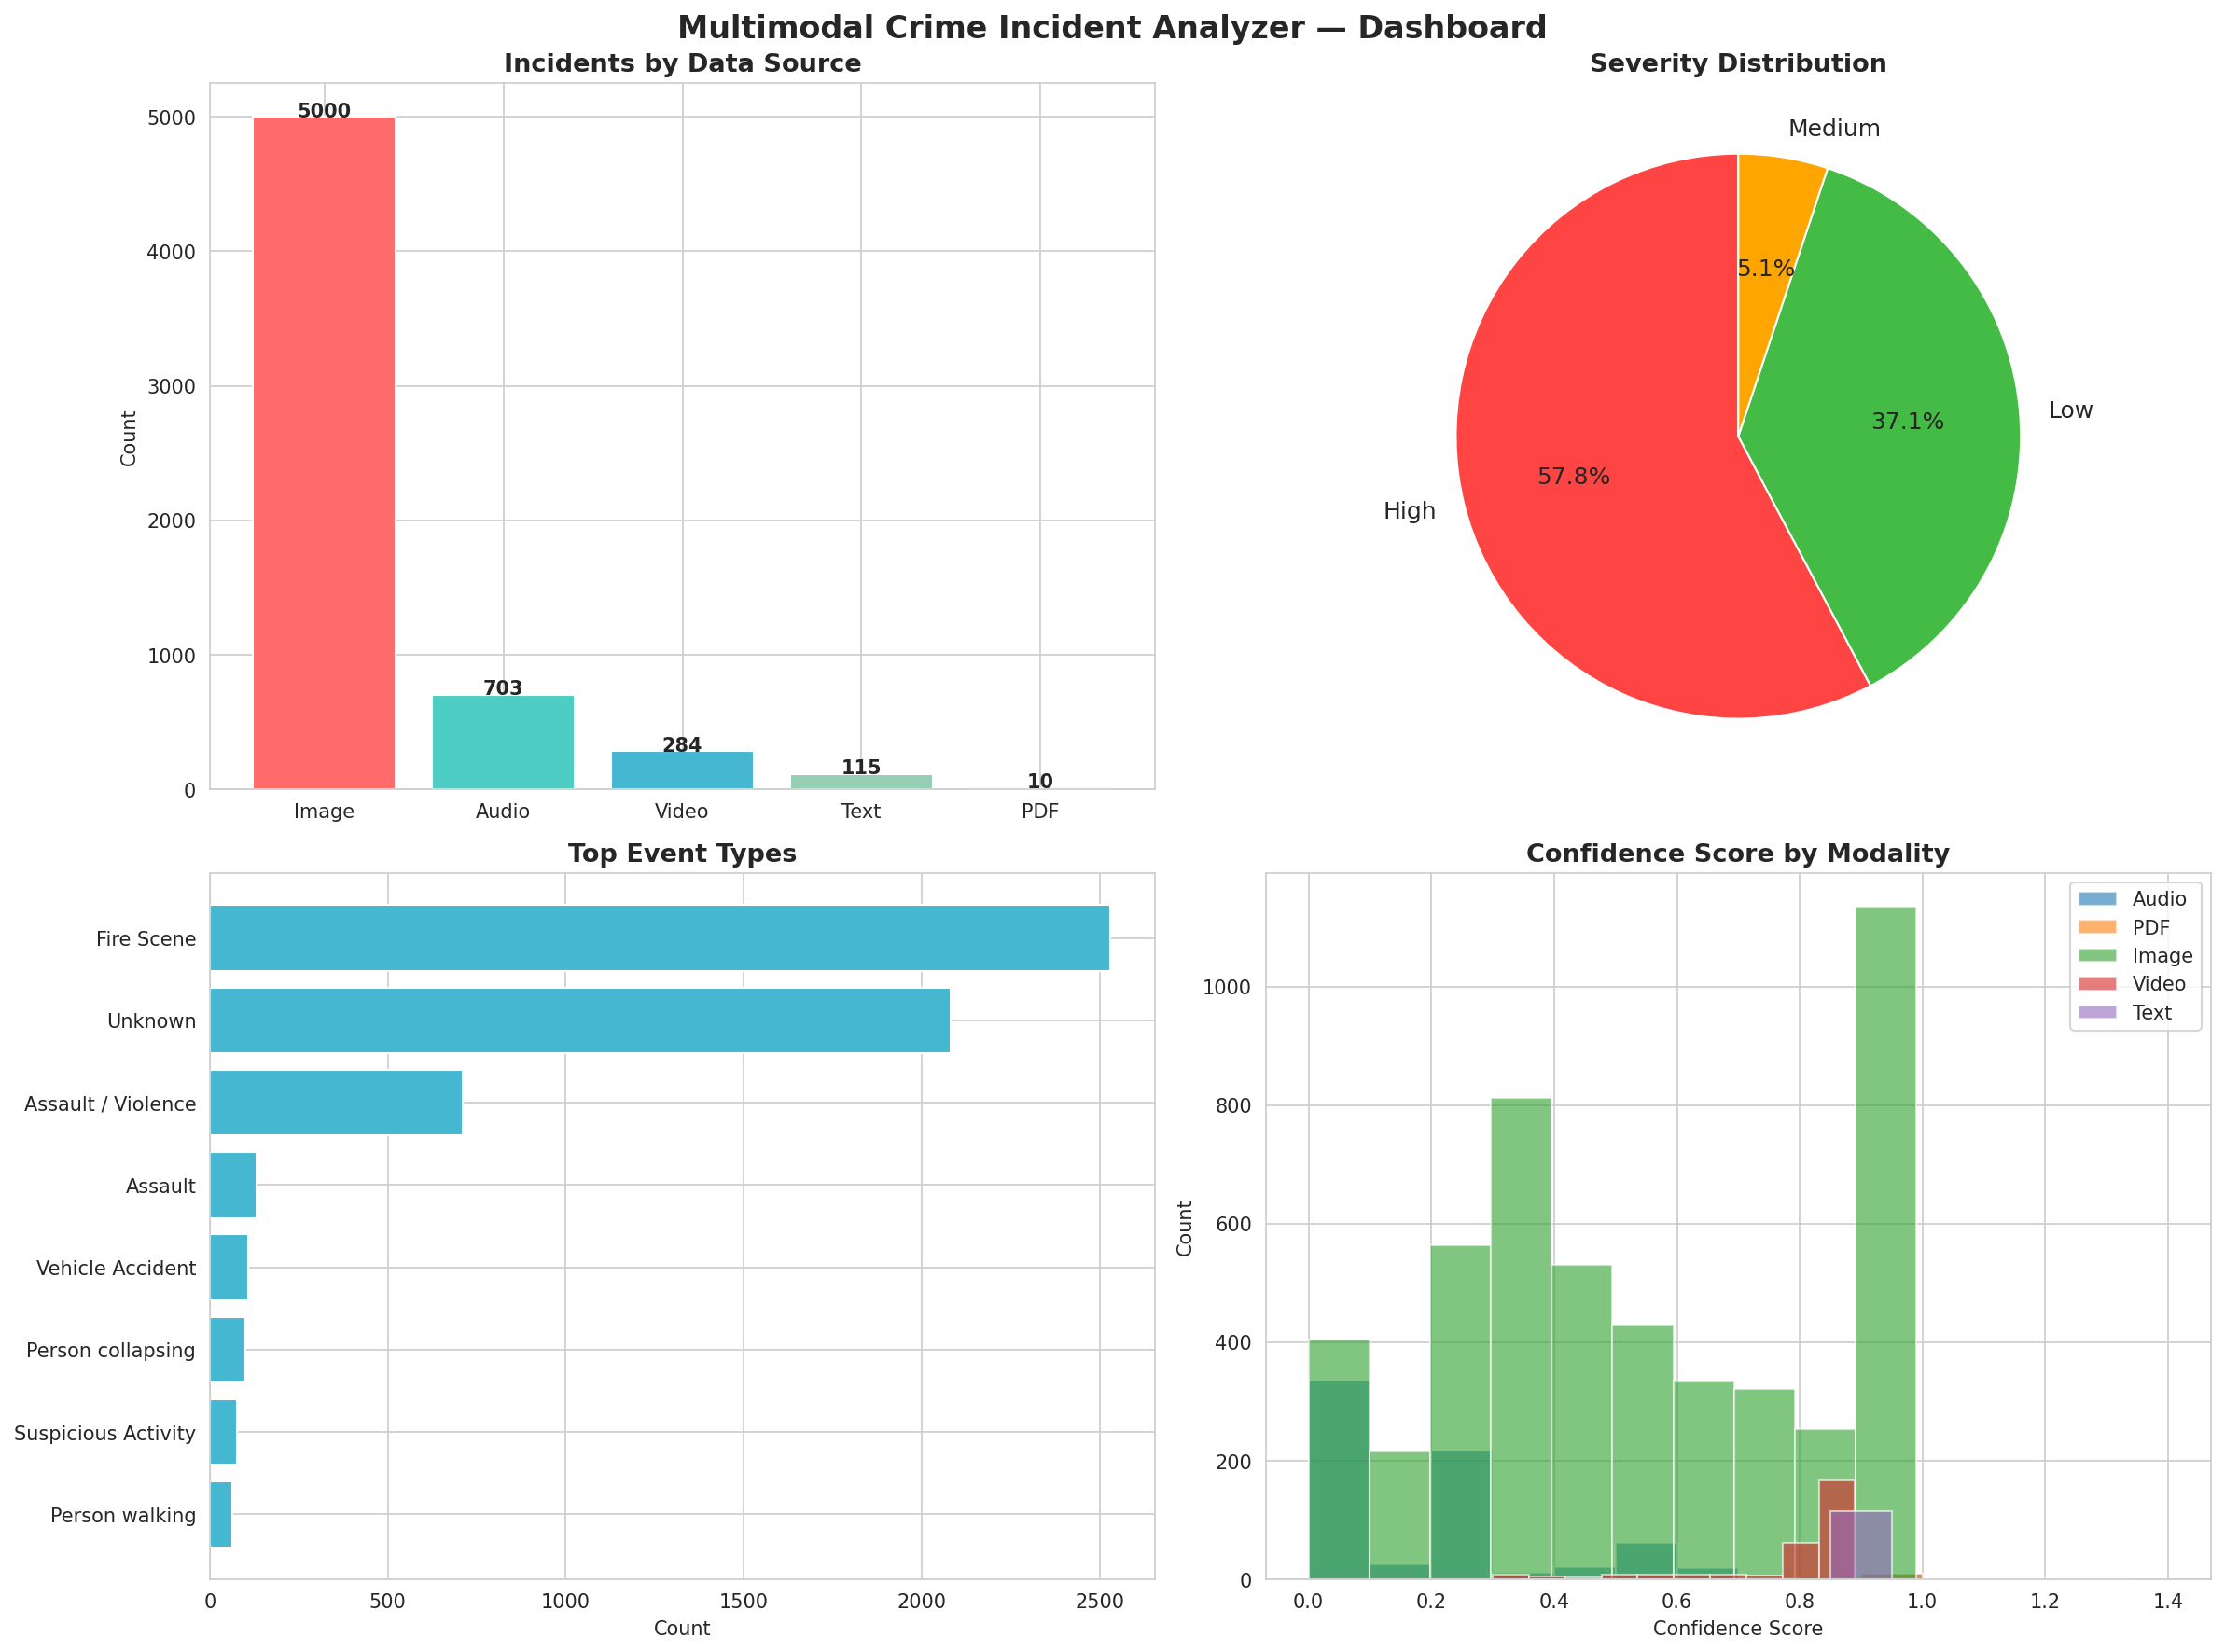

Dashboard saved to: dashboard.png


In [17]:
# =============================================
# CELL 9: Dashboard Visualizations
# =============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Multimodal Crime Incident Analyzer — Dashboard", fontsize=16, fontweight='bold')

# 1. Incidents by Source Modality
ax1 = axes[0, 0]
modality_counts = df_unified["Source_Modality"].value_counts()
colors_mod = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
ax1.bar(modality_counts.index, modality_counts.values, color=colors_mod[:len(modality_counts)])
ax1.set_title("Incidents by Data Source", fontsize=13, fontweight='bold')
ax1.set_ylabel("Count")
for i, v in enumerate(modality_counts.values):
    ax1.text(i, v + 0.2, str(v), ha='center', fontweight='bold')

# 2. Severity Distribution
ax2 = axes[0, 1]
severity_counts = df_unified["Severity"].value_counts()
colors_sev = {'High': '#FF4444', 'Medium': '#FFA500', 'Low': '#44BB44'}
sev_colors = [colors_sev.get(s, '#888888') for s in severity_counts.index]
ax2.pie(severity_counts.values, labels=severity_counts.index, colors=sev_colors,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
ax2.set_title("Severity Distribution", fontsize=13, fontweight='bold')

# 3. Top Event Types
ax3 = axes[1, 0]
event_counts = df_unified["Event_Type"].value_counts().head(8)
ax3.barh(range(len(event_counts)), event_counts.values, color='#45B7D1')
ax3.set_yticks(range(len(event_counts)))
ax3.set_yticklabels(event_counts.index, fontsize=10)
ax3.set_xlabel("Count")
ax3.set_title("Top Event Types", fontsize=13, fontweight='bold')
ax3.invert_yaxis()

# 4. Confidence Score Distribution
ax4 = axes[1, 1]
for modality in df_unified["Source_Modality"].unique():
    mod_data = df_unified[df_unified["Source_Modality"] == modality]["Confidence_Score"]
    ax4.hist(mod_data, bins=10, alpha=0.6, label=modality)
ax4.set_xlabel("Confidence Score")
ax4.set_ylabel("Count")
ax4.set_title("Confidence Score by Modality", fontsize=13, fontweight='bold')
ax4.legend()

plt.tight_layout()
plt.savefig("dashboard.png", dpi=150, bbox_inches='tight')
plt.show()

print("Dashboard saved to: dashboard.png")


In [18]:
# =============================================
# CELL 10: Simple Query Interface
# =============================================

def query_incidents(df, severity=None, modality=None, event_type=None, min_confidence=None):
    """Query the unified incident dataset."""
    result = df.copy()

    if severity:
        result = result[result["Severity"].str.lower() == severity.lower()]
    if modality:
        result = result[result["Source_Modality"].str.lower() == modality.lower()]
    if event_type:
        result = result[result["Event_Type"].str.lower().str.contains(event_type.lower())]
    if min_confidence is not None:
        result = result[result["Confidence_Score"] >= min_confidence]

    return result

# Example queries
print("=" * 70)
print("QUERY EXAMPLES")
print("=" * 70)

print("\n1. All HIGH severity incidents:")
print(query_incidents(df_unified, severity="High").to_string(index=False))

print("\n2. All fire-related incidents:")
print(query_incidents(df_unified, event_type="fire").to_string(index=False))

print("\n3. High-confidence incidents (>= 0.9):")
print(query_incidents(df_unified, min_confidence=0.9).to_string(index=False))

print("\n4. Audio modality incidents:")
print(query_incidents(df_unified, modality="Audio").to_string(index=False))


Streaming output truncated to the last 5000 lines.
          Image                            Fire Scene                      Scene Image        N/A             0.266    INC_4549     High
          Image                            Fire Scene                      Scene Image        N/A             0.990    INC_4550     High
          Image                            Fire Scene                      Scene Image        N/A             0.802    INC_4551     High
          Image                            Fire Scene                      Scene Image        N/A             0.990    INC_4552     High
          Image                    Assault / Violence                      Scene Image        N/A             0.500    INC_4553     High
          Image                            Fire Scene                      Scene Image        N/A             0.282    INC_4554     High
          Image                            Fire Scene                      Scene Image        N/A             0.344    INC_4555

### ✅ Integration Complete!

## Final Deliverables Checklist:

| # | Deliverable | Status |
|---|-------------|--------|
| 1 | AI Pipeline Architecture Diagram | Use the pipeline flow in this notebook |
| 2 | Code Repository (GitHub) | Organize into /audio, /pdf, /images, /video, /text, /integration |
| 3 | Structured Dataset | `final_unified_incidents.csv` + `final_integrated_wide.csv` + `final_merged_incidents.csv` |
| 4 | Project Report | Document approach, tools, datasets, challenges, results |
| 5 | Demonstration | Run this notebook end-to-end to show raw → structured flow |

## GitHub Repository Structure:
```
multimodal-crime-analyzer/
├── README.md
├── requirements.txt
├── audio/
│   └── audio_analyst.ipynb
├── pdf/
│   └── document_analyst.ipynb
├── images/
│   └── image_analyst.ipynb
├── video/
│   └── video_analyst.ipynb
├── text/
│   └── text_analyst.ipynb
├── integration/
│   └── integration.ipynb
└── outputs/
    ├── audio_analyst_output.csv
    ├── document_analyst_output.csv
    ├── image_analyst_output.csv
    ├── video_analyst_output.csv
    ├── text_analyst_output.csv
    |-- final_merged_incidents.csv
    ├── final_unified_incidents.csv
    ├── final_integrated_wide.csv
    └── dashboard.png
```
